### test 2a

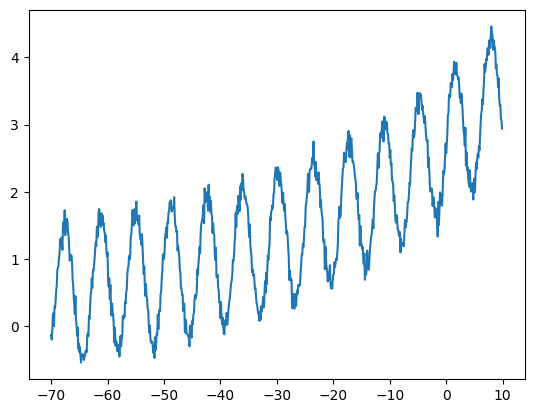

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X_t = np.arange(-70, 10, 0.1)

X_t = X_t.reshape(len(X_t), 1)
# Y_t = np.sin(X_t)
# Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1) + np.exp((0.5 * X_t + 20) * 0.05)

plt.plot(X_t, Y_t)
plt.show()

### test 2c

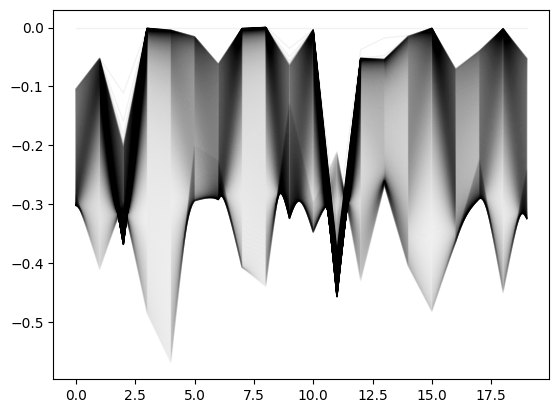

In [2]:
from LSTM import *

lstm = LSTM(n_neurons=200)
lstm.forward(X_t)

for c in lstm.C:
    plt.plot(np.arange(20), c[0:20], 'k-', linewidth=1, alpha=0.05)


In [3]:
# dir(lstm)

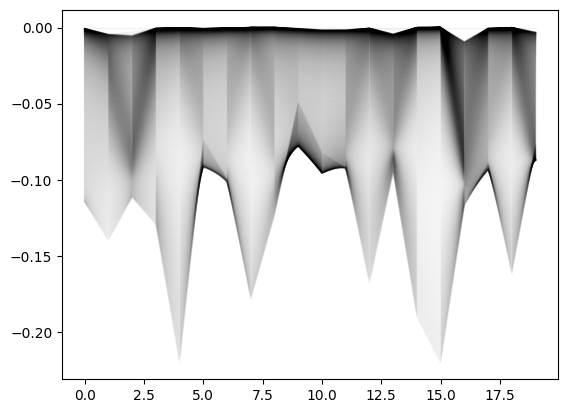

In [4]:
for h in lstm.H:
    plt.plot(np.arange(20), h[0:20], 'k-', linewidth=1, alpha=0.05)

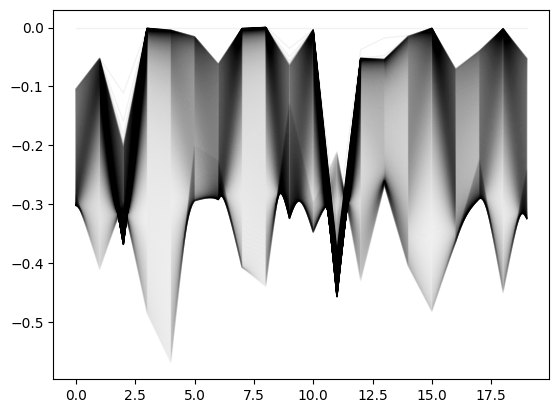

In [15]:
for c in lstm.C:
    plt.plot(np.arange(20), c[0:20], 'k-', linewidth=1, alpha=0.05)

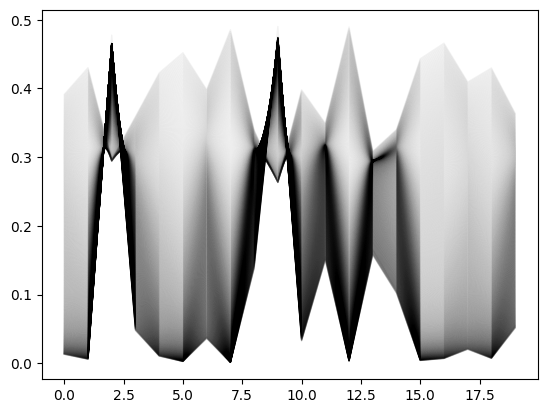

In [16]:
for f in lstm.F:
    plt.plot(np.arange(20), f[0:20], 'k-', linewidth=1, alpha=0.05)

## test 4

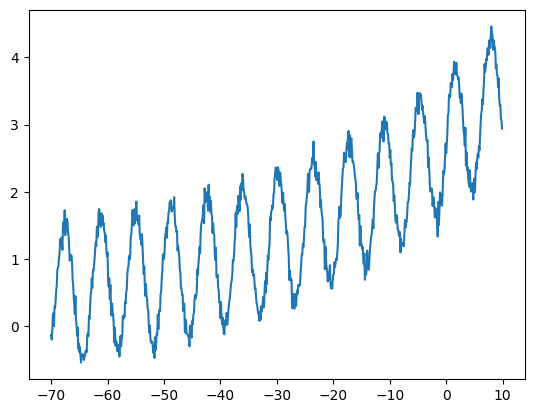

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X_t = np.arange(-70, 10, 0.1)

X_t = X_t.reshape(len(X_t), 1)
# Y_t = np.sin(X_t)
# Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1) + np.exp((0.5 * X_t + 20) * 0.05)

plt.plot(X_t, Y_t)
plt.show()

In [2]:
from LSTM import *

n_neurons = 200
lstm = LSTM(n_neurons)
T = max(X_t.shape)

In [3]:
lstm.forward(X_t)
H = lstm.H

In [4]:
len(H)

# 801 = T + 1

801

In [5]:
H = np.array(H)

In [6]:
H.shape

# (801, 200, 1)

(801, 200, 1)

In [7]:
H = H.reshape((H.shape[0], H.shape[1]))
# (801, 200)

In [8]:
H.shape

# (801, 200)

(801, 200)

In [9]:
H[:5]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

In [10]:
T

800

In [11]:
dense1 = Layer_Dense(n_neurons, T)
print(dense1.weights.shape)

(200, 800)


In [12]:
dense2 = Layer_Dense(T, 1)
print(dense2.weights.shape)

(800, 1)


C:\Users\moham\AppData\Local\Temp\ipykernel_14388\2223458071.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L  = float(0.5 * np.dot(dY.T, dY)/T)


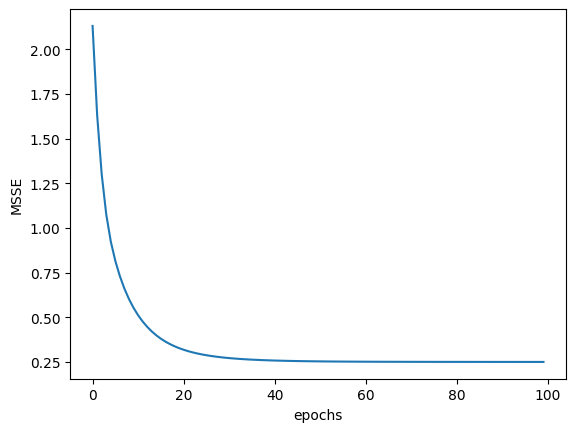

In [13]:
dense1 = Layer_Dense(n_neurons, T)
dense2 = Layer_Dense(T, 1)

lr = 1e-5
n_epoch = 100
Monitor = np.zeros((100))

for n in range(n_epoch):
    lstm.forward(X_t)
    H = np.array(lstm.H)
    H = H.reshape((H.shape[0], H.shape[1]))

    dense1.forward(H[1:, :])
    dense2.forward(dense1.output)

    Y_hat = dense2.output

    dY = Y_hat - Y_t

    L  = float(0.5 * np.dot(dY.T, dY)/T)

    Monitor[n] = L

    dense2.backward(dY)
    dense1.backward(dense2.dinputs)

    lstm.backward(dense1.dinputs)

    dense1.weights -= lr * dense1.dweights
    dense2.weights -= lr * dense2.dweights

    dense1.biases -= lr * dense1.dbiases
    dense2.biases -= lr * dense2.dbiases

    lstm.Uf -= lr * lstm.dUf
    lstm.Ui -= lr * lstm.dUi
    lstm.Uo -= lr * lstm.dUo
    lstm.Ug -= lr * lstm.dUg

    lstm.Wf -= lr * lstm.dWf
    lstm.Wi -= lr * lstm.dWi
    lstm.Wo -= lr * lstm.dWo
    lstm.Wg -= lr * lstm.dWg

    lstm.bf -= lr * lstm.dbf
    lstm.bi -= lr * lstm.dbi
    lstm.bo -= lr * lstm.dbo
    lstm.bg -= lr * lstm.dbg

    # print(f'current MSSE = {L: 0.3f} \n')

plt.plot(range(n_epoch), Monitor)
plt.xlabel("epochs")
plt.ylabel("MSSE")
plt.show()

#### Check with only one dense layer which is directly (200,1)

C:\Users\moham\AppData\Local\Temp\ipykernel_14388\3775341144.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L  = float(0.5 * np.dot(dY.T, dY)/T)


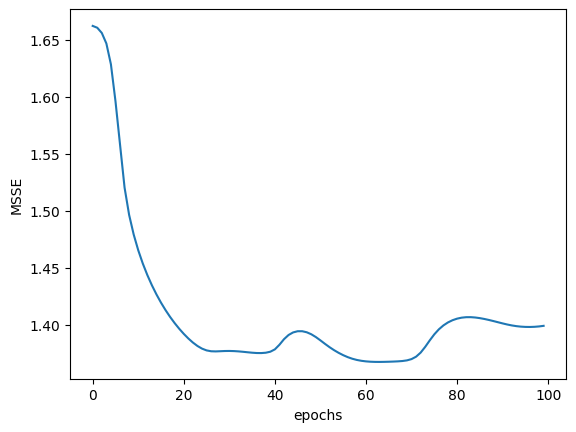

In [14]:
dense3 = Layer_Dense(n_neurons, 1)

lr = 1e-5
n_epoch = 100
Monitor = np.zeros((100))

for n in range(n_epoch):
    lstm.forward(X_t)
    H = np.array(lstm.H)
    H = H.reshape((H.shape[0], H.shape[1]))

    dense3.forward(H[1:, :])

    Y_hat = dense3.output

    dY = Y_hat - Y_t

    L  = float(0.5 * np.dot(dY.T, dY)/T)

    Monitor[n] = L

    dense2.backward(dY)
    dense1.backward(dense2.dinputs)

    lstm.backward(dense1.dinputs)

    dense1.weights -= lr * dense1.dweights
    dense2.weights -= lr * dense2.dweights

    dense1.biases -= lr * dense1.dbiases
    dense2.biases -= lr * dense2.dbiases

    lstm.Uf -= lr * lstm.dUf
    lstm.Ui -= lr * lstm.dUi
    lstm.Uo -= lr * lstm.dUo
    lstm.Ug -= lr * lstm.dUg

    lstm.Wf -= lr * lstm.dWf
    lstm.Wi -= lr * lstm.dWi
    lstm.Wo -= lr * lstm.dWo
    lstm.Wg -= lr * lstm.dWg

    lstm.bf -= lr * lstm.dbf
    lstm.bi -= lr * lstm.dbi
    lstm.bo -= lr * lstm.dbo
    lstm.bg -= lr * lstm.dbg

    # print(f'current MSSE = {L: 0.3f} \n')

plt.plot(range(n_epoch), Monitor)
plt.xlabel("epochs")
plt.ylabel("MSSE")
plt.show()